# Back-tilt of the subducting plate — the suppressed part of ridge push (STD vs WAL)

The asthenospheric return flow toward the ridge is driven by a pressure gradient that
**tilts the plate down toward the ridge**, suppressing the isostatic topography that
ridge push lives on. This notebook measures that suppression at the reference epoch for
both Fluidity cases, per `ANALYSIS_CONVENTIONS.md` §6b; the time series rides in
`../fluidity_time_evolution.ipynb`. **STD vs WAL is the controlled experiment** — only
the weak asthenospheric layer differs.

**Method (σ_zz register only):**

1. **Deep residual** $q_c(x) = -\left[\bar\sigma_{zz}^{deep}(x) - \bar\sigma_{zz}^{deep}(x_I)\right]$,
   averaged over the declared 120–190 km band (below $z_c = 75$ km; the asymptote panel
   justifies the band), smoothed 100 km. The native `p` is dynamic pressure relative to
   a 1-D reference, so **between-column differences are complete** (`MODEL.md`) and the
   construction is identical to the aspect repo's.
2. Counterfactual elevation $\Delta e(x) = -q_c/\rho g$ (back-tilt removed; display only).
3. **Back-tilt force** $F_{tilt} = -q_c(x_R)\,z_c$ (density-free — the $\rho$ in
   $\Delta e$ cancels against the $\rho g z_c$ of its GPE* contribution).
4. Partition: **isostatic ridge push = measured ridge push + $F_{tilt}$**; the back-tilt
   component can *move over* to ridge push as the channel evolves.

In [1]:
import sys, glob
from pathlib import Path
import numpy as np
if not hasattr(np, 'trapz'): np.trapz = np.trapezoid  # numpy 2.x compat
import natsort
import pyvista as pv
import matplotlib.pyplot as plt
import warnings, logging
from scipy.ndimage import gaussian_filter1d

pv.set_error_output_file(Path("/tmp/vtk_errors.log"))
logging.getLogger("pyvista").setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore", message="The VTK reader .*vtkXMLPUnstructuredGridReader.*")
plt.rcParams.update({"mathtext.fontset": "cm", "font.family": "serif"})

sys.path.insert(0, str(Path.cwd().parent))
from cerpa_helpers import (make_field_extractor, mirror_fields_in_x, pick_trench_3step,
                           find_first_isostatic_column, find_ridge_x, col_avg)

figures_dir = Path("figures"); figures_dir.mkdir(exist_ok=True)

In [2]:
# === Configuration ===========================================================
DATA_ROOT = "/Users/DSAND/DATA/numerical_models/OUTPUTS/"
MODELS = {"STD": "STD_RefModel", "WAL": "WAL_RefModel"}
TIMESTEP_INDEX = 10        # f10 = 20 Myr, the reference epoch (§4b); freely re-runnable
DX = 1000.0                # coarse grid is adequate for the basin-scale tilt
Z_DEEP = 200e3             # sampled depth extent (asymptote panel needs > deep band)
Z_C = 75e3                 # suite z_c (fluidity)
DEEP_BAND = (120e3, 190e3) # declared q_c band (§6b)
SMOOTH_KM = 100.0
WIN = 25                   # ±25 km cross-model column window (grid points at 1 km)
Y_SURFACE = 2_900_000.0
RHO_M, G = 3300.0, 9.8
MIRROR_X = True
SEAWARD_SIGN = +1
C_STD, C_WAL = "#002147", "#E5007D"


## 1. Load, extract, pick — both models

Register per `MODEL.md`: deviatoric `txx/tzz`, `txz` sign-flipped at read (y-up → z-down),
dynamic `p`; $\sigma_{zz} = \tau_{zz} - p$ (between-column differences complete); mirror applied.

In [3]:
def load_case(key):
    ff = natsort.natsorted(glob.glob(DATA_ROOT + MODELS[key] + "/subduction_with_LM*.pvtu"))[TIMESTEP_INDEX]
    vtk_data = pv.read(ff)
    vtk_data.point_data["p"] = vtk_data["NormalSP::Pressure"]
    vtk_data.point_data["txx"] = vtk_data["NormalSP::Stress"][:, 0]
    vtk_data.point_data["tzz"] = vtk_data["NormalSP::Stress"][:, 4]
    vtk_data.point_data["txz"] = -vtk_data["NormalSP::Stress"][:, 1]
    vtk_data.point_data["T"] = vtk_data["NormalSP::Temperature"]
    vtk_data.point_data["fs"] = vtk_data["NormalSP::FreeSurface"]
    vel = vtk_data["NormalSP::Velocity"] / 3.17098e-10
    vtk_data.point_data["vx"] = vel[:, 0]
    vtk_data.point_data["vy"] = vel[:, 1]
    t_myr = float(np.asarray(vtk_data["NormalSP::Time"]).flat[0]) / 31_557_600.0 / 1e6

    x_min, x_max, _, _, _, _ = vtk_data.bounds
    nx, nz = int((x_max - x_min) / DX), int(Z_DEEP / DX)
    x = x_min + (np.arange(nx) + 0.5) * DX
    z = (np.arange(nz) + 0.5) * DX
    X, Z = np.meshgrid(x, z, indexing="xy")
    grid = pv.StructuredGrid(X.T, (Y_SURFACE - Z).T, np.zeros_like(X.T))
    interp = grid.sample(vtk_data)
    nx_pv, nz_pv, _ = interp.dimensions
    valid = interp["vtkValidPointMask"].reshape((nx_pv, nz_pv), order="F").astype(bool)
    gfx = make_field_extractor(interp, nx_pv, nz_pv, valid)
    p, txx, tzz, txz = gfx("p"), gfx("txx"), gfx("tzz"), gfx("txz")
    T, fs, vx, vz = gfx("T"), gfx("fs"), gfx("vx"), -gfx("vy")
    if MIRROR_X:
        p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)

    szz = np.nan_to_num(tzz - p)
    fs_top = np.nan_to_num(fs[0, :])          # elevation, up-positive (w = -fs)

    x_T, _ = pick_trench_3step(x, z, p, vx, subducting_side="right")
    ti = int(np.argmin(np.abs(x - x_T)))
    iI, _ = find_first_isostatic_column(x, fs_top, x_T, ti, DX, seaward_sign=SEAWARD_SIGN)
    x_R, iR = find_ridge_x(x, fs_top, x_T, seaward_sign=SEAWARD_SIGN)

    zc = z <= Z_C
    gpe_star = -np.trapz(szz[zc], z[zc], axis=0)
    return dict(key=key, t_myr=t_myr, x=x, z=z, szz=szz, fs_top=fs_top,
                ti=ti, iI=iI, iR=iR, x_T=x_T, x_R=x_R, gpe_star=gpe_star)

cases = {k: load_case(k) for k in MODELS}
for c in cases.values():
    print(f"{c['key']}: t = {c['t_myr']:.1f} Myr   x_T = {c['x_T']/1e3:.0f}  "
          f"x_I = {c['x'][c['iI']]/1e3:.0f}  x_R = {c['x_R']/1e3:.0f} km")

STD: t = 20.0 Myr   x_T = 4392  x_I = 4466  x_R = 7832 km
WAL: t = 20.0 Myr   x_T = 4440  x_I = 4518  x_R = 7670 km


## 2. The deep residual $q_c(x)$ and its asymptote

The declared band must sit where $q_c(x_R)$ has stopped changing with depth — otherwise
it still mixes in lithospheric structure rather than measuring the sub-plate pressure
deficit (this is §8C's "equilibration is good, not perfect", made quantitative).

STD: q_c(x_R) = -9.30 MPa
WAL: q_c(x_R) = -8.92 MPa


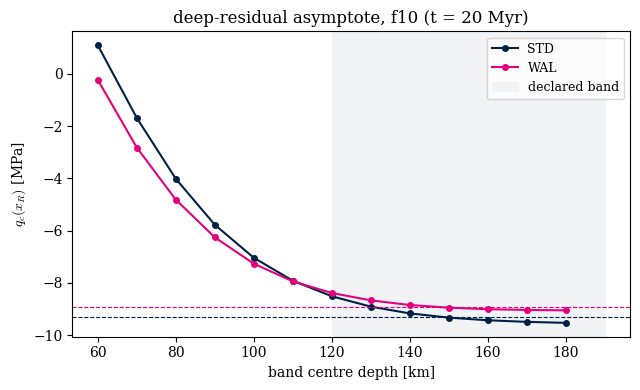

In [4]:
sm = lambda f: gaussian_filter1d(f, int(SMOOTH_KM * 1e3 / DX))

for c in cases.values():
    z, szz = c["z"], c["szz"]
    band = (z >= DEEP_BAND[0]) & (z <= DEEP_BAND[1])
    szz_deep = np.mean(szz[band], axis=0)
    c["q_c"] = sm(-(szz_deep - col_avg(szz_deep, c["iI"], WIN)))
    c["q_R"] = float(col_avg(c["q_c"], c["iR"], WIN))

    centers = np.arange(60e3, 186e3, 10e3)
    qd = []
    for cc in centers:
        b = (z >= cc - 15e3) & (z <= cc + 15e3)
        sd = np.mean(szz[b], axis=0)
        prof = sm(-(sd - col_avg(sd, c["iI"], WIN)))
        qd.append(float(col_avg(prof, c["iR"], WIN)))
    c["asym_centers"], c["asym_q"] = centers, np.array(qd)

fig, ax = plt.subplots(figsize=(6.5, 4))
for c, col in [(cases["STD"], C_STD), (cases["WAL"], C_WAL)]:
    ax.plot(c["asym_centers"] / 1e3, c["asym_q"] / 1e6, "o-", color=col, ms=4, label=c["key"])
    ax.axhline(c["q_R"] / 1e6, color=col, lw=0.8, ls="--")
ax.axvspan(DEEP_BAND[0]/1e3, DEEP_BAND[1]/1e3, color="#F2F3F5", label="declared band")
ax.set_xlabel("band centre depth [km]")
ax.set_ylabel("$q_c(x_R)$ [MPa]")
ax.set_title(f"deep-residual asymptote, f{TIMESTEP_INDEX} "
             f"(t = {cases['STD']['t_myr']:.0f} Myr)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(figures_dir / f"back_tilt_asymptote_f{TIMESTEP_INDEX}.png", dpi=140)
for c in cases.values():
    print(f"{c['key']}: q_c(x_R) = {c['q_R']/1e6:+.2f} MPa")

## 3. Back-tilt profile, counterfactual surface, and the partition

STD: trench pull +1.64  RP meas +1.14  F_tilt +0.70  RP iso +1.84 TN/m  (suppression 0.38)
WAL: trench pull +1.57  RP meas +0.86  F_tilt +0.67  RP iso +1.53 TN/m  (suppression 0.44)


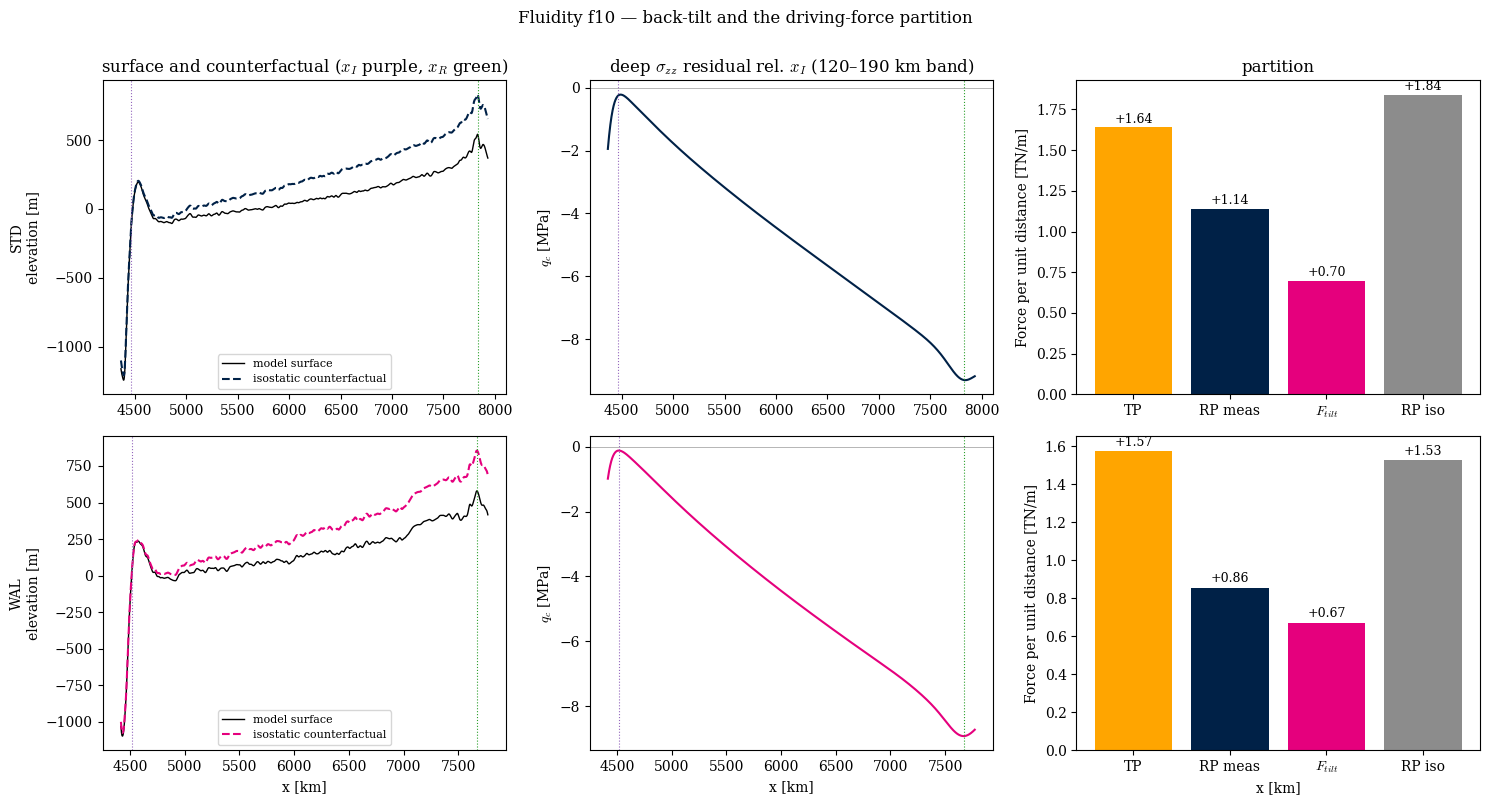

In [5]:
km = 1e3
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for r, (c, col) in enumerate([(cases["STD"], C_STD), (cases["WAL"], C_WAL)]):
    x, fs_top, q_c = c["x"], c["fs_top"], c["q_c"]
    ti, iI, iR = c["ti"], c["iI"], c["iR"]
    de = -q_c / (RHO_M * G)                    # display conversion only
    seg = (x >= x[iI] - 100e3) & (x <= x[iR] + 100e3)
    e_sm = gaussian_filter1d(fs_top, 10)

    ax = axes[r, 0]
    ax.plot(x[seg]/km, e_sm[seg], "k-", lw=1, label="model surface")
    ax.plot(x[seg]/km, (e_sm + de)[seg], "--", color=col, lw=1.5,
            label="isostatic counterfactual")
    ax.axvline(x[iI]/km, color="tab:purple", ls=":", lw=0.8)
    ax.axvline(x[iR]/km, color="tab:green", ls=":", lw=0.8)
    ax.set_ylabel(f"{c['key']}\nelevation [m]")
    ax.legend(fontsize=8)
    if r == 0:
        ax.set_title("surface and counterfactual ($x_I$ purple, $x_R$ green)")

    ax = axes[r, 1]
    ax.plot(x[seg]/km, q_c[seg]/1e6, "-", color=col)
    ax.axhline(0, color="0.6", lw=0.5)
    ax.axvline(x[iI]/km, color="tab:purple", ls=":", lw=0.8)
    ax.axvline(x[iR]/km, color="tab:green", ls=":", lw=0.8)
    ax.set_ylabel("$q_c$ [MPa]")
    if r == 0:
        ax.set_title("deep $\\sigma_{zz}$ residual rel. $x_I$ (120–190 km band)")

    gpe = c["gpe_star"]
    TP = float(col_avg(gpe, iI, WIN) - col_avg(gpe, ti, WIN))
    RP_meas = float(col_avg(gpe, iR, WIN) - col_avg(gpe, iI, WIN))
    F_tilt = -c["q_R"] * Z_C
    RP_iso = RP_meas + F_tilt
    c.update(TP=TP, RP_meas=RP_meas, F_tilt=F_tilt, RP_iso=RP_iso)

    ax = axes[r, 2]
    names = ["TP", "RP meas", "$F_{tilt}$", "RP iso"]
    vals = np.array([TP, RP_meas, F_tilt, RP_iso]) / 1e12
    ax.bar(names, vals, color=["orange", "#002147", "#E5007D", "0.55"])
    for i, v in enumerate(vals):
        ax.text(i, v + 0.03, f"{v:+.2f}", ha="center", fontsize=9)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylabel("Force per unit distance [TN/m]")
    if r == 0:
        ax.set_title("partition")

for ax in axes[-1]:
    ax.set_xlabel("x [km]")
fig.suptitle(f"Fluidity f{TIMESTEP_INDEX} — back-tilt and the driving-force partition", y=1.0)
fig.tight_layout()
fig.savefig(figures_dir / f"back_tilt_partition_f{TIMESTEP_INDEX}.png", dpi=140)

for c in cases.values():
    print(f"{c['key']}: trench pull {c['TP']/1e12:+.2f}  RP meas {c['RP_meas']/1e12:+.2f}  "
          f"F_tilt {c['F_tilt']/1e12:+.2f}  RP iso {c['RP_iso']/1e12:+.2f} TN/m  "
          f"(suppression {c['F_tilt']/c['RP_iso']:.2f})")

## Takeaways

* Both cases carry a deep pressure deficit under the ridge end of the plate — the
  ridge is dynamically held down, and roughly **a third to a half of the isostatic
  ridge push is suppressed** at the reference epoch.
* **A single epoch is a bad sample here.** The time series (partition figure in
  `../fluidity_time_evolution.ipynb`) shows STD sustaining roughly **twice** WAL's
  back-tilt through the run (STD ~0.5–1.0 TN/m; WAL decaying to ~0.1–0.3 TN/m by the
  late run) — the weak-asthenosphere case *does* suppress less ridge push, as the
  channel-viscosity picture predicts; at f10 the two happen to be near-coincident
  because WAL's decaying series is at a local high.
* The asymptote panel shows the 120–190 km band sits on the flat part of the depth
  dependence for both cases — consistent with §8C's single-column observation of a
  ~10 MPa persistent offset.

**Honesty box.** Deep band 120–190 km (declared, justified in §2); $q_c$ smoothed
100 km; column windows ±25 km; $z_c = 75$ km (the suite's fluidity value); ridge pick
`find_ridge_x` (50-km smoothed surface, 200-km outer-rise buffer); $\rho = 3300$
kg/m³ enters the displayed counterfactual elevation only — $F_{tilt}$ is density-free;
$x_I$ from the repo's fs-recovery picker (declared deviation from the suite's
$dV/dx$ form); coarse 1-km grid (adequate for a basin-scale signal).